<img src="https://www.epfl.ch/about/overview/wp-content/uploads/2020/07/logo-epfl-1024x576.png" style="padding-right:10px;width:140px;float:left">

<h1 style="white-space: nowrap;">Neural Signals and Signal Processing (NX-421)</h1>
<h2>Miniproject 1 — Fall 2025</h2>

<p><strong>Project title:</strong> Data Driven Analysis of Motor Activation Patterns in fMRI with GLM and K-Means Clustering</p>
<p><strong>Group X Team Members:</strong> Changlan Chen; Davide Micheletti; Gianmarco Placì; Vincenzo Rivieccio; Pasquale Scognamiglio </p>

<hr style="clear:both">

This Notebook contains the code required to perform a discriminatory analysis during an fMRI task, specifically in understanding what are the brain regions that activate when a subject moves hands or feet.

# Part 1

**Structural Preprocessing: Skull-stripping and Segmentation**

In [1]:
%gui wx
import sys
import os

#####################
# Import of utils.py functions
#####################
# Required to get utils.py and access its functions
notebook_dir = os.path.abspath("")
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
sys.path.append(parent_dir)
sys.path.append('.')
from utils import loadFSL, FSLeyesServer, mkdir_no_exist, interactive_MCQ

####################
# DIPY_HOME should be set prior to import of dipy to make sure all downloads point to the right folder
####################
os.environ["DIPY_HOME"] = "/home/jovyan/Data"


#############################
# Loading fsl and freesurfer within Neurodesk
# You can find the list of available other modules by clicking on the "Softwares" tab on the left
#############################
import lmod
await lmod.purge(force=True)
await lmod.load('fsl/6.0.7.4')
await lmod.load('freesurfer/7.4.1')
await lmod.list()

####################
# Setup FSL path
####################
loadFSL()

###################
# Load all relevant libraries for the lab
##################
import fsl.wrappers
from fsl.wrappers import fslmaths

import mne_nirs
import nilearn
from nilearn.datasets import fetch_development_fmri

import mne
import mne_nirs
import dipy
from dipy.data import fetch_bundles_2_subjects, read_bundles_2_subjects
import xml.etree.ElementTree as ET
import os.path as op
import nibabel as nib
import glob

import ants

import openneuro
from mne.datasets import sample
from mne_bids import BIDSPath, read_raw_bids, print_dir_tree, make_report


# Useful imports to define the direct download function below
import requests
import urllib.request
from tqdm import tqdm


# FSL function wrappers which we will call from python directly
from fsl.wrappers import fast, bet
from fsl.wrappers.misc import fslroi
from fsl.wrappers import flirt

# General purpose imports to handle paths, files etc
import glob
import pandas as pd
import numpy as np
import json
import subprocess

In [3]:
################
# Start FSLeyes (very neat tool to visualize MRI data of all sorts) within Python
################
fsleyesDisplay = FSLeyesServer()
fsleyesDisplay.show()

In [4]:
data_dir = "data"
# Functional LR
func_LR = os.path.join(data_dir, "fMRI", "tfMRI_MOTOR_LR", "tfMRI_MOTOR_LR.nii")
events_LR = os.path.join(data_dir, "fMRI", "tfMRI_MOTOR_LR", "events_LR.csv")

# Functional RL
func_RL = os.path.join(data_dir, "fMRI", "tfMRI_MOTOR_RL", "tfMRI_MOTOR_RL.nii")
events_RL = os.path.join(data_dir, "fMRI", "tfMRI_MOTOR_RL", "events_RL.csv")

# Anatomical
anat_path = os.path.join(data_dir, "T1w", "T1w.nii.gz")

bids_root    = data_dir
preproc_root = os.path.join(bids_root, "derivatives", "preprocessed_data")
mkdir_no_exist(preproc_root)

In [5]:
# Skull stripping
def get_skull_stripped_anatomical(bids_root, preproc_root, subject_id, robust=False):
    """
    Function to perform skull-stripping (removing the skull around the brain).
    This is a simple wrapper around the brain extraction tool (BET) in FSL's suite
    It assumes data to be in the BIDS format (which we will cover in the following weeks).
    The method also saves the brain mask which was used to extract the brain.

    The brain extraction is conducted only on the T1w of the participant.

    Parameters
    ----------
    bids_root: string
        The root of the BIDS directory
    preproc_root: string
        The root of the preprocessed data, where the result of the brain extraction will be saved.
    subject_id: string
        Subject ID, the subject on which brain extraction should be conducted.
    robust: bool
        Whether to conduct robust center estimation with BET or not. Default is False.
    """
    # We perform here skull stripping
    anatomical_path   = op.join(bids_root, "T1w", "T1w.nii.gz")
    betted_brain_path = op.join(preproc_root, "T1w_brain")
    mkdir_no_exist(preproc_root)

    os.system('bet {} {} -m {}'.format(anatomical_path, betted_brain_path, '-R' if robust else ''))
    print("Done with BET.")

resulting_mask_path = os.path.join(preproc_root, "T1w_brain_mask.nii.gz")
get_skull_stripped_anatomical(bids_root, preproc_root, "001", robust=True)

Done with BET.


In [6]:
# Skull stripping visualization
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(op.join(bids_root, "T1w", "T1w.nii.gz"))
fsleyesDisplay.load(op.join(preproc_root, "T1w_brain.nii.gz"))
fsleyesDisplay.load(resulting_mask_path)


(ipykernel_launcher.py:870): Gdk-WARNING **: 17:49:50.002: gdkdrawable-x11.c:952 drawable is not a pixmap or window


In [7]:
# Tissue segmentation
anatomical_path = op.join(bids_root, "T1w", "T1w.nii.gz")
bet_path = op.join(preproc_root, "T1w_brain.nii.gz")

fast_target = bet_path # Use bet_path as target of segmentation to avoid misclassification of non-brain tissues

[os.remove(f) for f in glob.glob(op.join(preproc_root,'*fast*'))] # Just to clean the directory in between runs of the cell
segmentation_path = op.join(preproc_root, "T1w_fast")
fast(imgs=[fast_target], out=segmentation_path, n_classes=3)

{}

In [8]:
# Segmentation visualization
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(bet_path)
fsleyesDisplay.load(glob.glob(op.join(preproc_root,'*pve_0*'))[0]) # CSF
fsleyesDisplay.load(glob.glob(op.join(preproc_root,'*pve_1*'))[0]) # GM
fsleyesDisplay.load(glob.glob(op.join(preproc_root,'*pve_2*'))[0]) # WM
fsleyesDisplay.displayCtx.getOpts(fsleyesDisplay.overlayList[1]).cmap = 'Red'
fsleyesDisplay.displayCtx.getOpts(fsleyesDisplay.overlayList[2]).cmap = 'Green'
fsleyesDisplay.displayCtx.getOpts(fsleyesDisplay.overlayList[3]).cmap = 'Blue'

**Functional Preprocessing: Concatenation, Motion Correction, Co-registration, Gaussian smoothing**

In [9]:
# Variance normalization and concatenation
import subprocess
import os

# First of all, define the paths to the runs that need to be concatenated
OUTDIR = "/neurodesktop-storage/nx421_sub-101410"
os.makedirs(OUTDIR, exist_ok=True)

R1 = "data/fMRI/tfMRI_MOTOR_LR/tfMRI_MOTOR_LR.nii.gz"
R2 = "data/fMRI/tfMRI_MOTOR_RL/tfMRI_MOTOR_RL.nii.gz"

# Compute the temporal mean of the first run to obtain a representative image for brain masking
subprocess.run(["fslmaths", R1, "-Tmean", f"{OUTDIR}/mean_LR.nii.gz"], check=True)
# and then perform skull stripping on the mean image to generate a brain mask
subprocess.run(["bet", f"{OUTDIR}/mean_LR.nii.gz", f"{OUTDIR}/brainLR", "-m", "-f", "0.3"], check=True)
MASK = f"{OUTDIR}/brainLR_mask.nii.gz"

MASK_R2 = f"{OUTDIR}/brainLR_mask_resampled_to_RL.nii.gz"
subprocess.run([
    "flirt", "-in", MASK, "-ref", R2,
    "-applyxfm", "-usesqform",
    "-out", MASK_R2
], check=True)

# Rescaling variance to 1
def get_std(img, mask):
    result = subprocess.run(["fslstats", img, "-k", mask, "-S"], capture_output=True, text=True, check=True)
    return float(result.stdout.strip())

s1 = get_std(R1, MASK)
s2 = get_std(R2, MASK_R2)   
print(f"STD LR = {s1:.4f}, STD RL = {s2:.4f}")

subprocess.run(["fslmaths", R1, "-div", str(s1), f"{OUTDIR}/tfMRI_MOTOR_LR_varscaled.nii.gz"], check=True)
subprocess.run(["fslmaths", R2, "-div", str(s2), f"{OUTDIR}/tfMRI_MOTOR_RL_varscaled.nii.gz"], check=True)

# Concatenation
subprocess.run([
    "fslmerge", "-t", f"{OUTDIR}/tfMRI_MOTOR_concat_varscaled.nii.gz",
    f"{OUTDIR}/tfMRI_MOTOR_LR_varscaled.nii.gz",
    f"{OUTDIR}/tfMRI_MOTOR_RL_varscaled.nii.gz"
], check=True)

print("Concatenation completed!")

# Check 
import subprocess

def get_dim4(img):
    result = subprocess.run(["fslinfo", img], capture_output=True, text=True)
    for line in result.stdout.splitlines():
        if "dim4" in line:
            return line.strip()

imgs = [
    "/neurodesktop-storage/nx421_sub-101410/tfMRI_MOTOR_LR_varscaled.nii.gz",
    "/neurodesktop-storage/nx421_sub-101410/tfMRI_MOTOR_RL_varscaled.nii.gz",
    "/neurodesktop-storage/nx421_sub-101410/tfMRI_MOTOR_concat_varscaled.nii.gz"
]

for path in imgs:
    print(get_dim4(path))

print("Concatenation verified.")

STD LR = 3118.8264, STD RL = 3083.0424
Concatenation completed!
dim4		284
dim4		284
dim4		568
Concatenation verified.


In [10]:
# Motion correction
from fsl.wrappers import mcflirt
import pathlib

# Paths
OUTDIR = "/neurodesktop-storage/nx421_sub-101410"
pathlib.Path(OUTDIR).mkdir(parents=True, exist_ok=True)

LR_VAR = f"{OUTDIR}/tfMRI_MOTOR_LR_varscaled.nii.gz"
RL_VAR = f"{OUTDIR}/tfMRI_MOTOR_RL_varscaled.nii.gz"
LR_MC  = f"{OUTDIR}/tfMRI_MOTOR_LR_mc.nii.gz"
RL_MC  = f"{OUTDIR}/tfMRI_MOTOR_RL_mc.nii.gz"

print("Running MCFLIRT on LR and RL...")
mcflirt(infile=LR_VAR, out=LR_MC, dof=6, meanvol=True, plots=True, mats=True)
mcflirt(infile=RL_VAR, out=RL_MC, dof=6, meanvol=True, plots=True, mats=True)
print("Done with MCFLIRT.")

Running MCFLIRT on LR and RL...
Done with MCFLIRT.


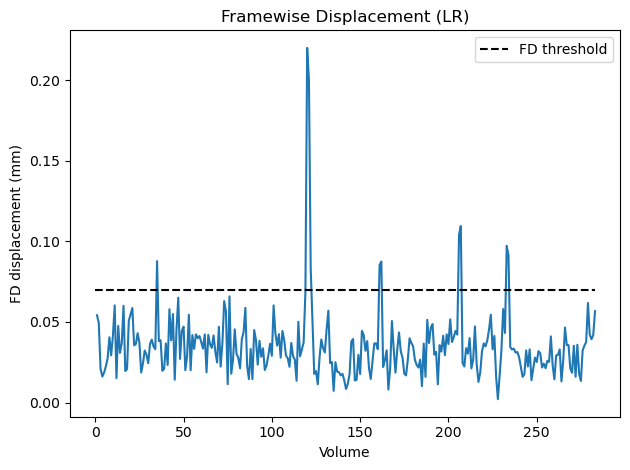

[LR] meanFD=0.035  maxFD=0.220  #>thr=10
Indices of frames above threshold: [35, 120, 121, 122, 161, 162, 206, 207, 233, 234]


<Figure size 640x480 with 0 Axes>

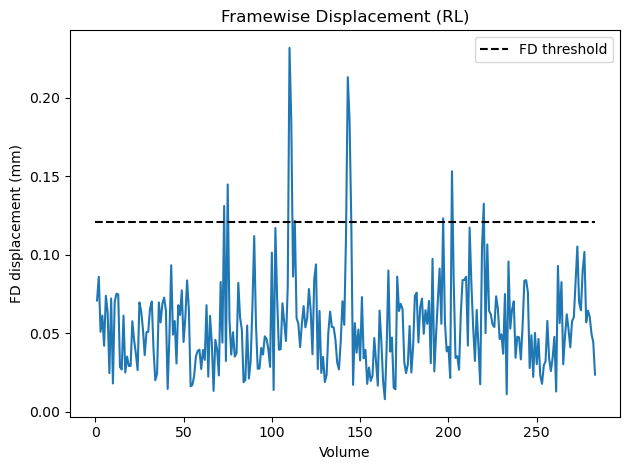

[RL] meanFD=0.055  maxFD=0.232  #>thr=10
Indices of frames above threshold: [73, 75, 110, 111, 113, 143, 144, 197, 202, 220]
Concatenation (post-MC) completed!


<Figure size 640x480 with 0 Axes>

In [11]:
def load_mot_params_fsl_6_dof(path):
    return pd.read_csv(path, sep='  ', header=None, 
            engine='python', names=['Rotation x', 'Rotation y', 'Rotation z','Translation x', 'Translation y', 'Translation z'])

def compute_FD_power(mot_params):
    framewise_diff = mot_params.diff().iloc[1:]

    rot_params = framewise_diff[['Rotation x', 'Rotation y', 'Rotation z']]
    # Estimating displacement on a 50mm radius sphere
    # To know this one, we can remember the definition of the radian!
    # Indeed, let the radian be theta, the arc length be s and the radius be r.
    # Then theta = s / r
    # We want to determine here s, for a sphere of 50mm radius and knowing theta. Easy enough!
    
    # Another way to think about it is through the line integral along the circle.
    # Integrating from 0 to theta with radius 50 will give you, unsurprisingly, r0 theta.
    converted_rots = rot_params*50
    trans_params = framewise_diff[['Translation x', 'Translation y', 'Translation z']]
    fd = converted_rots.abs().sum(axis=1) + trans_params.abs().sum(axis=1)
    return fd

# FD, IQR threshold, plot and indices above threshold (for LR and RL)
def fd_block(mc_out_path, tag, save_confounds=True):
    import glob
    matches = glob.glob(mc_out_path + "*.par")
    assert len(matches) > 0, f"No .par file found for {mc_out_path}"
    par_path = matches[0]

    mot_params = load_mot_params_fsl_6_dof(par_path)
    fd = compute_FD_power(mot_params).to_numpy()

    # threshold IQR: Q3 + 1.5*(Q3 - Q1)
    q3, q1 = np.quantile(fd, 0.75), np.quantile(fd, 0.25)
    threshold = q3 + 1.5 * (q3 - q1)

    # plot FD (show + save)
    plt.figure()
    plt.plot(range(1, fd.size + 1), fd)
    plt.xlabel('Volume')
    plt.ylabel('FD displacement (mm)')
    plt.hlines(threshold, 0, len(fd), colors='black', linestyles='dashed', label='FD threshold')
    plt.legend()
    plt.title(f"Framewise Displacement ({tag})")
    plt.tight_layout()
    plt.show()  # shows the plot in the notebook
    plt.savefig(os.path.join(OUTDIR, f"{tag}_fd.png"), dpi=150)

    # print and indexes above threshold (count from 1)
    bad_idx = (np.where(fd > threshold)[0] + 1).tolist()
    print(f"[{tag}] meanFD={fd.mean():.3f}  maxFD={fd.max():.3f}  #>thr={len(bad_idx)}")
    print(f"Indices of frames above threshold: {bad_idx}")

    # save FD and confounds (one-hot)
    np.savetxt(os.path.join(OUTDIR, f"{tag}_fd.txt"), fd, fmt="%.6f")
    if save_confounds:
        if len(bad_idx) == 0:
            open(os.path.join(OUTDIR, f"{tag}_confounds.txt"), "w").close()
        else:
            conf = np.zeros((len(fd), len(bad_idx)), dtype=int)
            for j, v in enumerate(bad_idx):
                conf[v - 1, j] = 1 
            np.savetxt(os.path.join(OUTDIR, f"{tag}_confounds.txt"), conf, fmt="%d")
import matplotlib.pyplot as plt
# run for LR and RL
fd_block(LR_MC, "LR", save_confounds=True)
fd_block(RL_MC, "RL", save_confounds=True)

# Concatenation after MC
import subprocess

OUTDIR = "/neurodesktop-storage/nx421_sub-101410"
LR_MC  = f"{OUTDIR}/tfMRI_MOTOR_LR_mc.nii.gz"
RL_MC  = f"{OUTDIR}/tfMRI_MOTOR_RL_mc.nii.gz"
CONCAT = f"{OUTDIR}/tfMRI_MOTOR_concat_mc.nii.gz"

subprocess.run([
    "fslmerge", "-t", CONCAT, LR_MC, RL_MC
], check=True)

print("Concatenation (post-MC) completed!")

In [12]:
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(LR_VAR)
fsleyesDisplay.load(LR_MC)

#fsleyesDisplay.resetOverlays()
#fsleyesDisplay.load(RL_VAR)
#fsleyesDisplay.load(RL_MC)

In [13]:
#Coregistration (really long time to run)
from fsl.wrappers import epi_reg
# Done for the middle single slice of LR 

# We use the motion corrected EPI
epi_source = LR_MC
whole_t1 = op.join(bids_root, 'T1w', 'T1w.nii.gz')
skull_stripped_t1 = op.join(preproc_root, "T1w_brain.nii.gz")
output_path = op.join(OUTDIR, 'fMRI_coregistration')
ref_vol_name =  op.join(OUTDIR, 'fMRI_coregistration_vol_middle')

use_single_vol = True

if use_single_vol:
    # Extract the middle volume with fslroi as we've seen before 
    fslroi(epi_source, ref_vol_name, str(283), str(1))
    # Call epi_reg
    subprocess.run(['epi_reg','--epi={}'.format(ref_vol_name), '--t1={}'.format(whole_t1), '--t1brain={}'.format(skull_stripped_t1), '--out={}'.format(output_path)])
else:
    subprocess.run(['epi_reg','--epi={}'.format(epi_source), '--t1={}'.format(whole_t1), '--t1brain={}'.format(skull_stripped_t1), '--out={}'.format(output_path)])


Running FAST segmentation
FLIRT pre-alignment
Running BBR
0.989052 0.999494 -0.031513 0.004324 0.000000 0.031728 0.997375 -0.065094 0.000000 -0.002262 0.065199 0.997870 0.000000 -4.406076 -2.385436 13.001481 1.000000 


In [14]:
Coregistration = op.join(OUTDIR, 'fMRI_coregistration')
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(skull_stripped_t1)
fsleyesDisplay.load(output_path)

In [15]:
#Smoothing
# Done for the middle single slice of LR 
smoothing_source = LR_MC
output_path = op.join(OUTDIR, 'fMRI_smoothing')

fslroi(smoothing_source, output_path, str(283), str(1))

cmd = 'fslmaths {} -s {} {}_smoothed-6mm'.format(output_path, 6/2.3548, output_path)
subprocess.run(['fslmaths',output_path, '-s', str(6/2.3548), '{}_smoothed-6mm'.format(output_path)])

CompletedProcess(args=['fslmaths', '/neurodesktop-storage/nx421_sub-101410/fMRI_smoothing', '-s', '2.547987090198743', '/neurodesktop-storage/nx421_sub-101410/fMRI_smoothing_smoothed-6mm'], returncode=0)

In [16]:
#Smoothing
# For the whole volume 
smoothing_source = LR_MC
output_path = op.join(OUTDIR, 'fMRI_smoothing_total')

#fslroi(smoothing_source, output_path, str(283), str(1))

cmd = 'fslmaths {} -s {} {}_smoothed-6mm'.format(smoothing_source, 6/2.3548, output_path)
subprocess.run(['fslmaths',smoothing_source, '-s', str(6/2.3548), '{}_smoothed-6mm'.format(output_path)])

CompletedProcess(args=['fslmaths', '/neurodesktop-storage/nx421_sub-101410/tfMRI_MOTOR_LR_mc.nii.gz', '-s', '2.547987090198743', '/neurodesktop-storage/nx421_sub-101410/fMRI_smoothing_total_smoothed-6mm'], returncode=0)

In [17]:
# Smoothing
# For the whole volume (LR + RL)
smoothing_source = op.join(OUTDIR, 'tfMRI_MOTOR_LR_RL_mc_concat.nii.gz')
output_path = op.join(OUTDIR, 'fMRI_smoothing_total')

subprocess.run([
    'fslmerge', '-t', smoothing_source,
    f'{OUTDIR}/tfMRI_MOTOR_LR_mc.nii.gz',
    f'{OUTDIR}/tfMRI_MOTOR_RL_mc.nii.gz'
], check=True)

cmd = 'fslmaths {} -s {} {}_smoothed-6mm'.format(smoothing_source, 6/2.3548, output_path)
subprocess.run(['fslmaths', smoothing_source, '-s', str(6/2.3548),
                '{}_smoothed-6mm'.format(output_path)])

CompletedProcess(args=['fslmaths', '/neurodesktop-storage/nx421_sub-101410/tfMRI_MOTOR_LR_RL_mc_concat.nii.gz', '-s', '2.547987090198743', '/neurodesktop-storage/nx421_sub-101410/fMRI_smoothing_total_smoothed-6mm'], returncode=0)

smooth_path = op.join(OUTDIR, 'fMRI_smoothing_total_smoothed-6mm.nii.gz')
fsleyesDisplay.resetOverlays()
fsleyesDisplay.load(smooth_path)

In [ ]:
#smooth_path

GLM

In [18]:
data_path_LR = "data/fMRI/tfMRI_MOTOR_LR/events_LR.csv"
events_LR = pd.read_table(data_path_LR, sep = ",")
events_LR = events_LR.rename(columns={"condition":"trial_type"})
events_LR

,onset,duration,trial_type
0,0.0,8.0,NaN
1,8.0,3.0,cue
2,11.0,12.0,rh
3,23.0,3.0,cue
4,26.0,12.0,lf
5,38.0,3.0,cue
6,41.0,12.0,t
7,53.0,3.0,cue
8,56.0,12.0,rf
9,68.0,3.0,cue


In [19]:
# Load all required files for GLM (no merging needed)

import os
import os.path as op
import pandas as pd

# Base directories
OUTDIR = "/neurodesktop-storage/nx421_sub-101410"
DATADIR = "data/fMRI"

# Functional data (motion-corrected + smoothed, LR+RL combined)
func_file = op.join(OUTDIR, "fMRI_smoothing_total_smoothed-6mm.nii.gz")
assert op.exists(func_file), f"Missing functional file: {func_file}"

# Brain mask
mask_file = op.join(OUTDIR, "brainLR_mask.nii.gz")
assert op.exists(mask_file), f"Missing brain mask: {mask_file}"

# Combined events file
# Combine individual event files if not already done
events_LR = pd.read_csv(op.join("data/fMRI/tfMRI_MOTOR_LR/events_LR.csv"))
events_RL = pd.read_csv(op.join("data/fMRI/tfMRI_MOTOR_RL/events_RL.csv"))
for df in (events_LR, events_RL):
    df['condition'] = df['condition'].astype(str).str.strip().str.lower()
    # from nan to fixation
    #df['condition'].replace({'nan': np.nan}, inplace=True)
    #df['condition'] = df['condition'].fillna('fixation')
    # eliminate nan
    df['condition'].replace({'': pd.NA, 'nan': pd.NA}, inplace=True)
    df.dropna(subset=['condition'], inplace=True)
end_LR = (events_LR['onset'] + events_LR['duration']).max()
events_RL['onset'] = events_RL['onset'] + end_LR

# Concatenate both runs
events_all = pd.concat([events_LR, events_RL], ignore_index=True)
events_all = events_all.sort_values('onset', kind='mergesort').reset_index(drop=True)

# Save combined file
events_all_path = op.join(OUTDIR, "events_all.csv")
events_all.to_csv(events_all_path, index=False)
print(f"Combined events file saved to: {events_all_path}")
events_all_path = op.join(OUTDIR, "events_all.csv")
assert op.exists(events_all_path), f"Missing events file: {events_all_path}"

# Load events
events = pd.read_csv(events_all_path, sep=None, engine="python")

# Load confounds
confounds_LR = pd.read_csv(op.join(OUTDIR, "LR_confounds.txt"), sep="\t")
confounds_RL = pd.read_csv(op.join(OUTDIR, "RL_confounds.txt"), sep="\t")

# Concatenate both runs
confounds_all = pd.concat([confounds_LR, confounds_RL], ignore_index=True)
confounds_path = op.join(OUTDIR, "confounds_all.txt")
confounds_all.to_csv(confounds_path, sep="\t", index=False)
assert op.exists(confounds_path), f"Missing confounds file: {confounds_path}"
conf_all = np.loadtxt(confounds_path)

# Check the columns
print("Functional file:", func_file)
print("Mask file:", mask_file)
print("Events file:", events_all_path)
print("Confounds shape:", conf_all.shape)
print("Event columns:", list(events.columns))
print(events)

Combined events file saved to: /neurodesktop-storage/nx421_sub-101410/events_all.csv
Functional file: /neurodesktop-storage/nx421_sub-101410/fMRI_smoothing_total_smoothed-6mm.nii.gz
Mask file: /neurodesktop-storage/nx421_sub-101410/brainLR_mask.nii.gz
Events file: /neurodesktop-storage/nx421_sub-101410/events_all.csv
Confounds shape: (565, 10)
Event columns: ['onset', 'duration', 'condition']
    onset  duration condition
0     8.0       3.0       cue
1    11.0      12.0        rh
2    23.0       3.0       cue
3    26.0      12.0        lf
4    38.0       3.0       cue
5    41.0      12.0         t
6    53.0       3.0       cue
7    56.0      12.0        rf
8    68.0       3.0       cue
9    71.0      12.0        lh
10   83.0      15.0  fixation
11   98.0       3.0       cue
12  101.0      12.0         t
13  113.0       3.0       cue
14  116.0      12.0        lf
15  128.0       3.0       cue
16  131.0      12.0        rh
17  143.0      16.0  fixation
18  159.0       3.0       cue
19  

/tmp/ipykernel_870/3522159490.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['condition'].replace({'': pd.NA, 'nan': pd.NA}, inplace=True)
/tmp/ipykernel_870/3522159490.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [20]:
import pandas as pd
import os.path as op
import numpy as np

# Load and normalize events
events = pd.read_csv(op.join(OUTDIR, "events_all.csv"), sep=None, engine="python")

# Normalize headers
norm = {c: c.strip().lower().replace(' (s)','').replace(' ','_') for c in events.columns}
events.columns = [norm[c] for c in events.columns]

# Common aliases
alias = {
    'onsets': 'onset', 'start': 'onset', 'start_time': 'onset',
    'dur': 'duration', 'length': 'duration',
    'condition': 'trial_type', 'trialtype': 'trial_type', 'trial-name': 'trial_type', 'name': 'trial_type'
}
for a, b in alias.items():
    if a in events.columns and b not in events.columns:
        events = events.rename(columns={a: b})

# Ensure required columns
missing = {'onset', 'duration', 'trial_type'} - set(events.columns)
if missing:
    raise ValueError(f"Events missing required columns: {missing}. Current: {list(events.columns)}")

# Type checks
events['onset'] = pd.to_numeric(events['onset'], errors='raise')
events['duration'] = pd.to_numeric(events['duration'], errors='raise')
events['trial_type'] = events['trial_type'].astype(str)

print("Events validated successfully!")
print(events)

Events validated successfully!
    onset  duration trial_type
0     8.0       3.0        cue
1    11.0      12.0         rh
2    23.0       3.0        cue
3    26.0      12.0         lf
4    38.0       3.0        cue
5    41.0      12.0          t
6    53.0       3.0        cue
7    56.0      12.0         rf
8    68.0       3.0        cue
9    71.0      12.0         lh
10   83.0      15.0   fixation
11   98.0       3.0        cue
12  101.0      12.0          t
13  113.0       3.0        cue
14  116.0      12.0         lf
15  128.0       3.0        cue
16  131.0      12.0         rh
17  143.0      16.0   fixation
18  159.0       3.0        cue
19  162.0      12.0         lh
20  174.0       3.0        cue
21  177.0      12.0         rf
22  189.0      15.5   fixation
23  212.5       3.0        cue
24  215.5      12.0         lh
25  227.5       3.0        cue
26  230.5      12.0         rf
27  242.5      15.0   fixation
28  257.5       3.0        cue
29  260.5      12.0          t
30  272.

In [21]:
# Fit the GLM on your ready files
from nilearn.glm.first_level import FirstLevelModel

# Fit the GLM including confounds
TR = 0.72
fmri_glm = FirstLevelModel(
    t_r=TR,
    noise_model='ar1',
    standardize=False,
    hrf_model='spm',
    drift_model=None,
    high_pass=0.01,
    mask_img=mask_file
)

fmri_glm = fmri_glm.fit(func_file, events)
print("GLM fitted successfully with confound regressors.")

GLM fitted successfully with confound regressors.


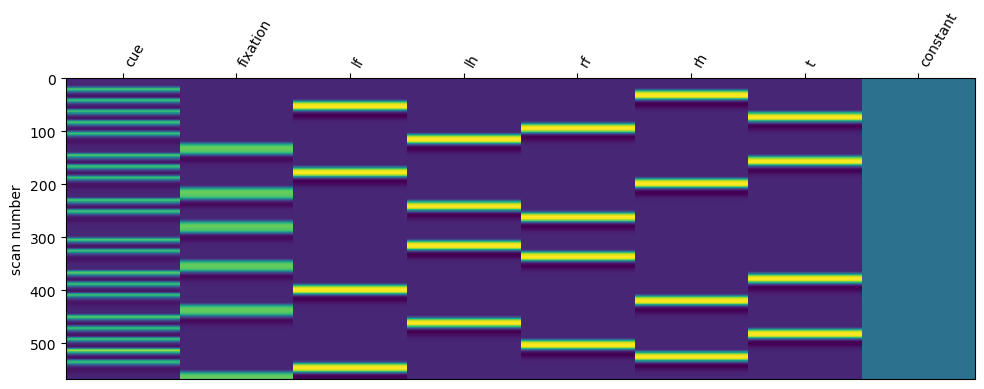

Design matrix saved at: /neurodesktop-storage/nx421_sub-101410/design_matrix.png
Columns: ['cue', 'fixation', 'lf', 'lh', 'rf', 'rh', 't', 'constant']


In [22]:
# Inspect the design matrix and save it
from nilearn.plotting import plot_design_matrix
import matplotlib.pyplot as plt

dm = fmri_glm.design_matrices_[0]
ax = plot_design_matrix(dm)
ax.figure.set_size_inches(10, 4)
plt.tight_layout()

# Save and show
plt.savefig(op.join(OUTDIR, "design_matrix.png"), dpi=200)
plt.show()

print("Design matrix saved at:", op.join(OUTDIR, "design_matrix.png"))
print("Columns:", list(dm.columns))

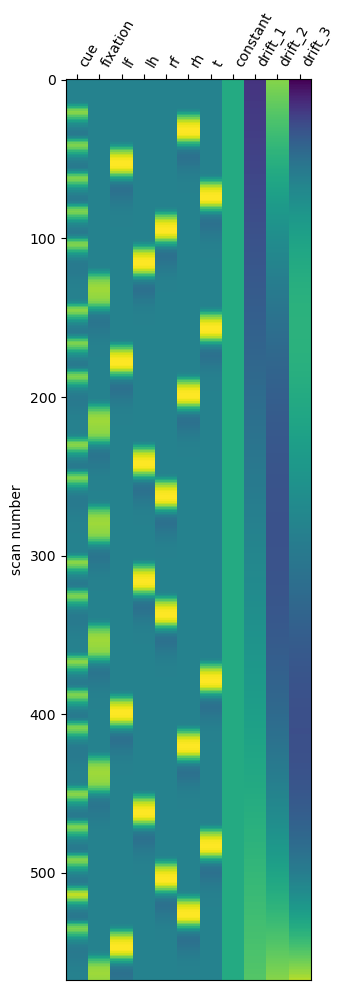

In [23]:
#Trying adding drift regressors
from nilearn.glm.first_level.design_matrix import _make_drift

column_values, column_names = _make_drift(drift_model='polynomial', frame_times=np.asarray(list(range(0, 568, 1))), order=3, high_pass=None)
dm = fmri_glm.design_matrices_[0]
for (col, name) in zip(column_values.T, column_names):
    dm[name] = col

plot_design_matrix(dm)
plt.show()

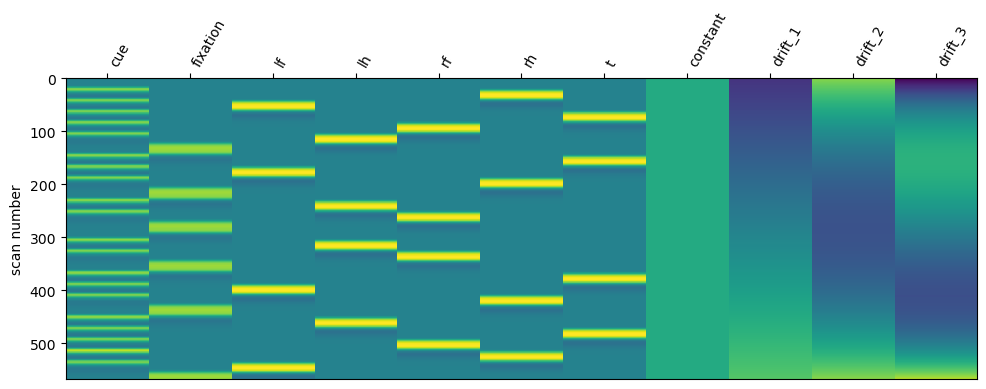

Design matrix saved at: /neurodesktop-storage/nx421_sub-101410/design_matrix2.png
Columns: ['cue', 'fixation', 'lf', 'lh', 'rf', 'rh', 't', 'constant', 'drift_1', 'drift_2', 'drift_3']


In [24]:
ax = plot_design_matrix(dm)
ax.figure.set_size_inches(10, 4)
plt.tight_layout()

# Save and show
plt.savefig(op.join(OUTDIR, "design_matrix2.png"), dpi=200)
plt.show()

print("Design matrix saved at:", op.join(OUTDIR, "design_matrix2.png"))
print("Columns:", list(dm.columns))

In [25]:
fit_glm = FirstLevelModel(t_r=0.72, drift_model='None')
fit_glm.fit(func_file, design_matrices=[dm])

FirstLevelModel(drift_model='None', t_r=0.72)

Design matrix columns:
 ['cue', 'fixation', 'lf', 'lh', 'rf', 'rh', 't', 'constant', 'drift_1', 'drift_2', 'drift_3']
Task regressors considered in contrasts:
 ['cue', 'fixation', 'lf', 'lh', 'rf', 'rh', 't', 'drift_1', 'drift_2', 'drift_3']
Z-map computed and saved!


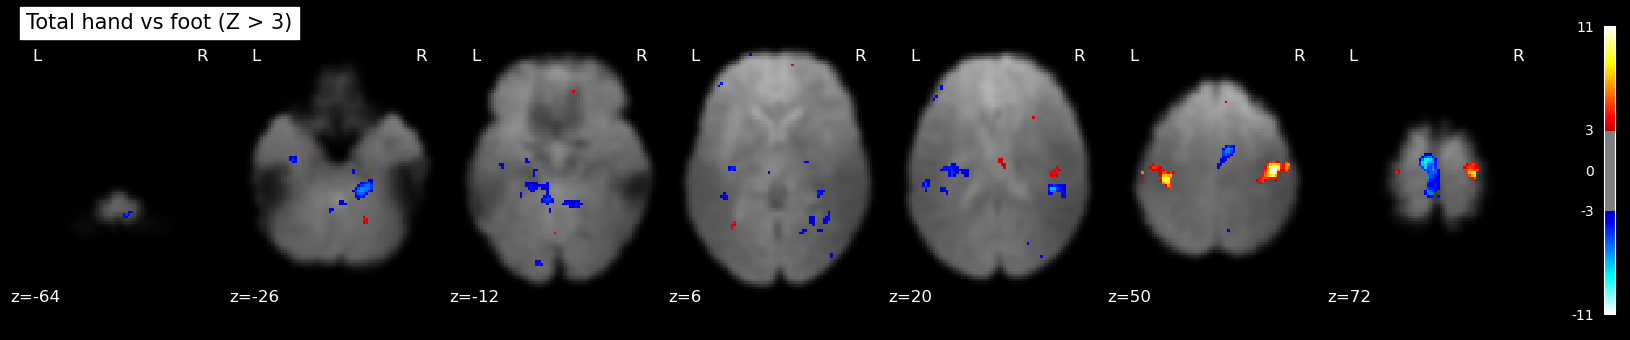

In [26]:
# Define contrasts based on trial types in the design matrix

import numpy as np
import os.path as op
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.image import mean_img
from nilearn.plotting import plot_stat_map

# Extract design columns
design_columns = list(fmri_glm.design_matrices_[0].columns)
print("Design matrix columns:\n", design_columns)

# Identify only task-related columns (exclude confounds and intercept)
task_cols = [c for c in design_columns if not c.startswith('reg') and 'constant' not in c.lower()]
print("Task regressors considered in contrasts:\n", task_cols)

# Define contrasts
contrasts = {}

contrasts['left_hand_foot'] = np.array([
    1 if c == 'lh' else (-1 if c == 'lf' else 0)
    for c in design_columns
])

contrasts['right_hand_foot'] = np.array([
    1 if c == 'rh' else (-1 if c == 'rf' else 0)
    for c in design_columns
])

# average of both hands vs both feet
contrasts['total_hand_foot'] = (contrasts['left_hand_foot'] + contrasts['right_hand_foot']) / 2

# Compute and save the contrast
z_map = fit_glm.compute_contrast(contrasts['total_hand_foot'], output_type='z_score')
nib.save(z_map, op.join(OUTDIR, 'z_total_hand_foot.nii.gz'))
print("Z-map computed and saved!")

# Plot
plot_stat_map(
    z_map,
    bg_img=mean_img(func_file),
    threshold=3.0,
    display_mode='z',
    cut_coords=7,
    black_bg=True,
    title='Total hand vs foot (Z > 3)'
)
plt.show()

Task regressors retained: ['cue', 'fixation', 'lf', 'lh', 'rf', 'rh', 't']


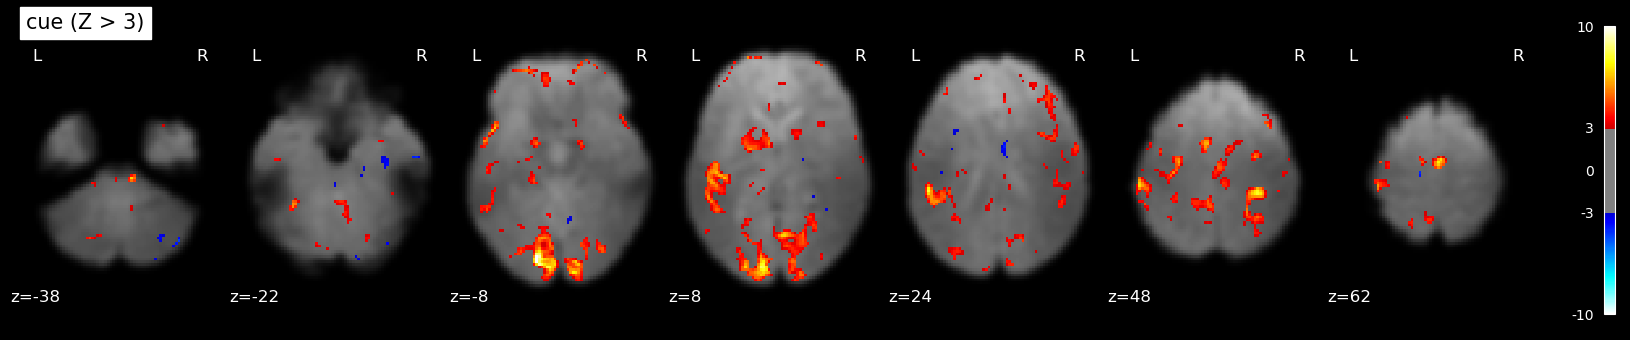

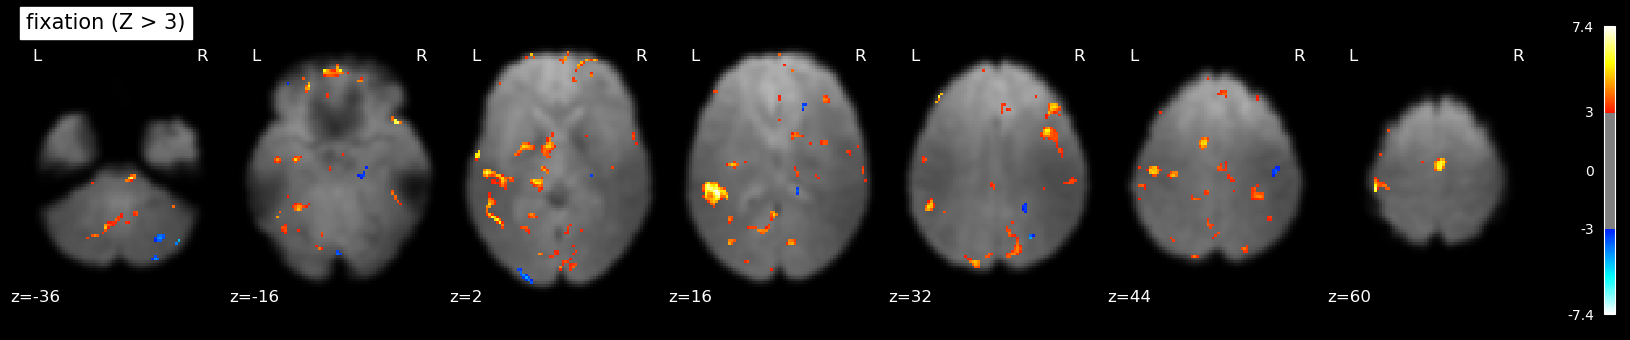

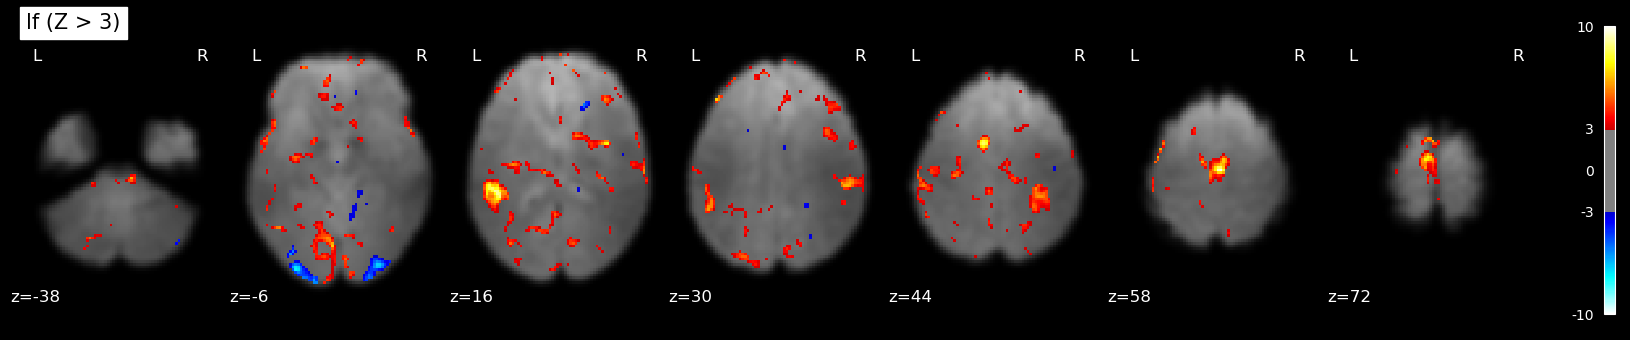

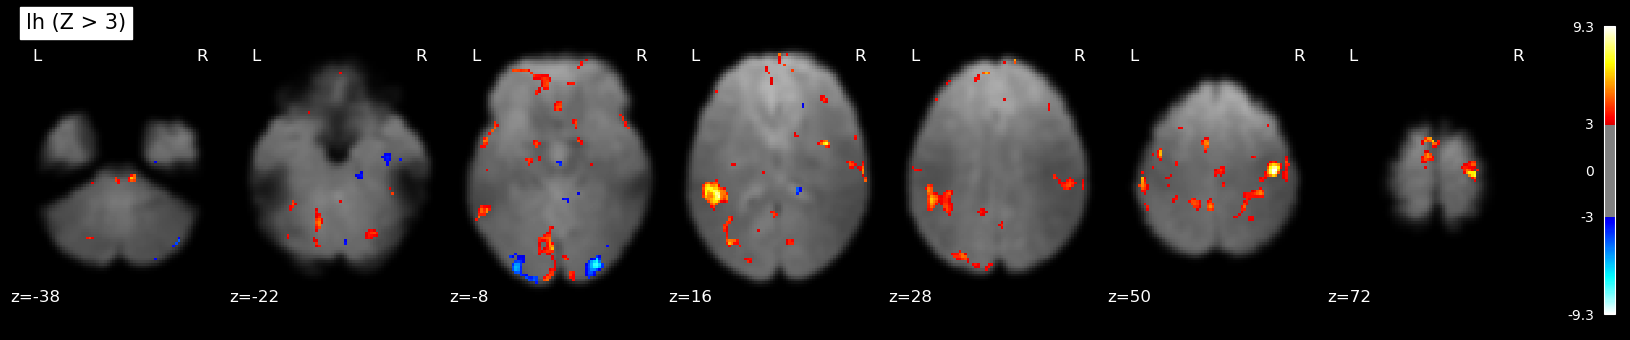

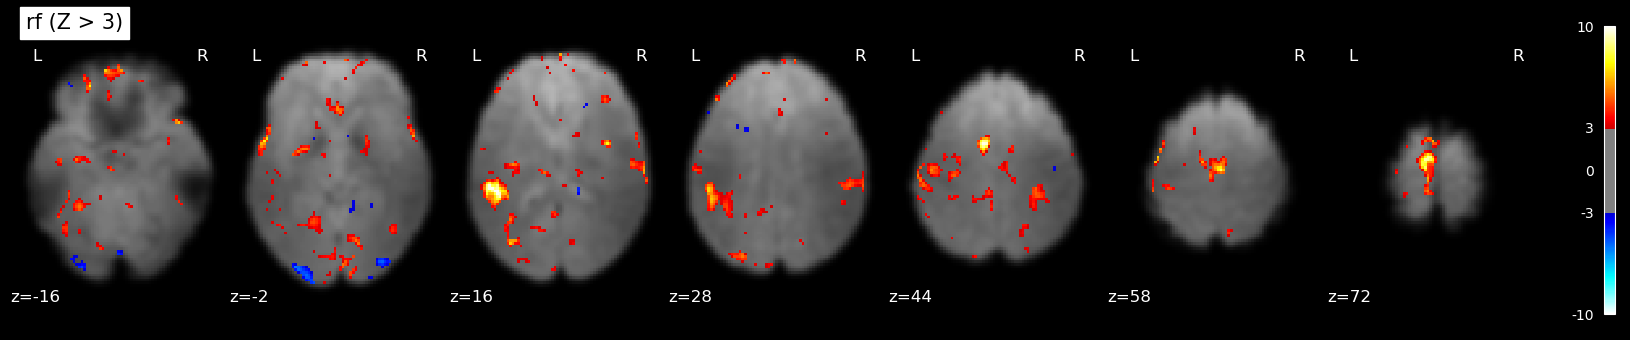

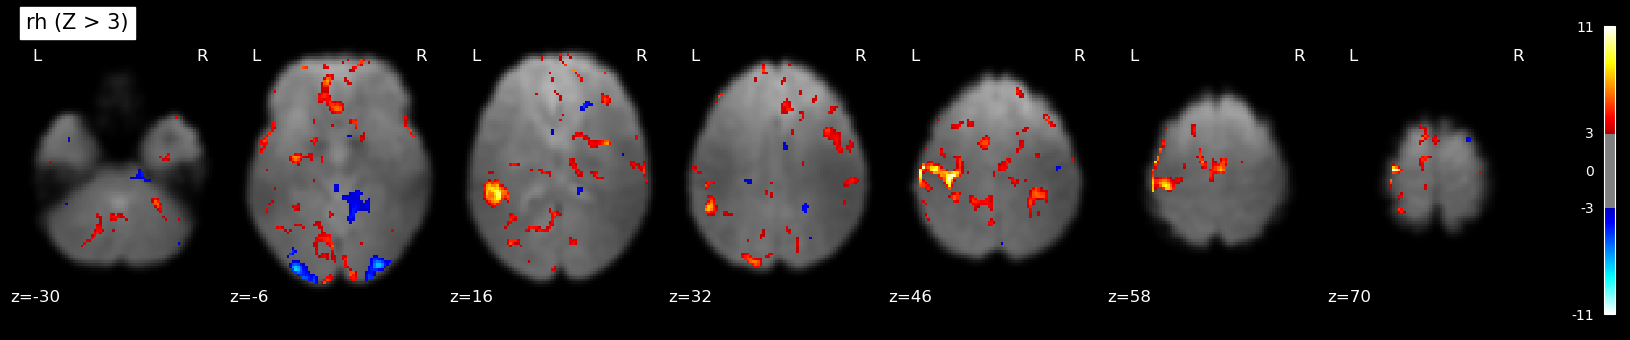

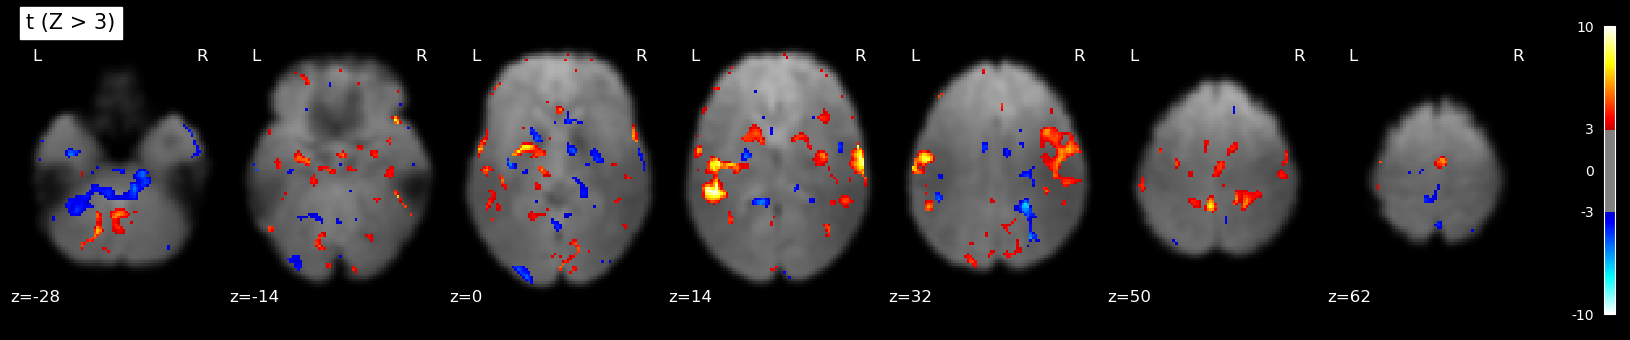

Saved per-regressor Z and beta maps to: /neurodesktop-storage/nx421_sub-101410


In [27]:
# Compute a Z-map (and optionally beta-map) for EACH task regressor
import numpy as np
import nibabel as nib
from nilearn.image import mean_img
from nilearn.plotting import plot_stat_map
import matplotlib.pyplot as plt
import os.path as op

dm_cols = list(fit_glm.design_matrices_[0].columns)

# Pick only task columns (exclude confounds, constant, drift)
task_cols = [
    c for c in dm_cols
    if not c.lower().startswith("reg")   # exclude confounds
    and "drift" not in c.lower()
    and "constant" not in c.lower()
    and "intercept" not in c.lower()
]

print("Task regressors retained:", task_cols)

bg = mean_img(func_file)

for col in task_cols:
    # Build unit contrast for this single task regressor
    w = np.array([1.0 if c == col else 0.0 for c in dm_cols])

    # Z-map
    zmap = fit_glm.compute_contrast(w, output_type="z_score")
    nib.save(zmap, op.join(OUTDIR, f"z_{col}.nii.gz"))

    # Beta-map (effect size)
    betamap = fit_glm.compute_contrast(w, output_type="effect_size")
    nib.save(betamap, op.join(OUTDIR, f"beta_{col}.nii.gz"))

    # Visualization
    plot_stat_map(
        zmap,
        bg_img=bg,
        threshold=3.0,
        display_mode='z',
        cut_coords=7,
        black_bg=True,
        title=f"{col} (Z > 3)"
    )
    plt.show()

print("Saved per-regressor Z and beta maps to:", OUTDIR)

Task columns used for contrast computation:
 ['cue', 'fixation', 'lf', 'lh', 'rf', 'rh', 't']


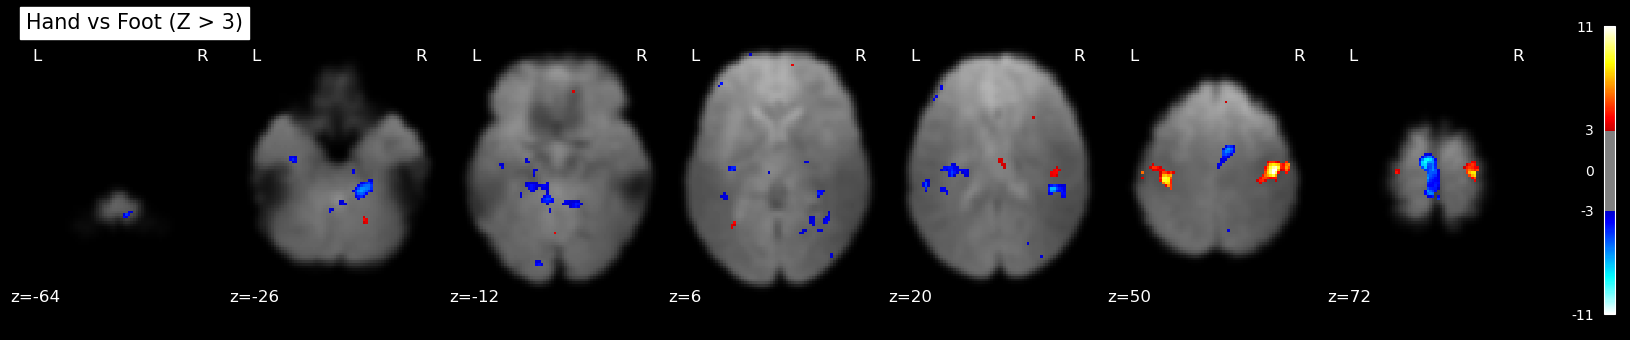

Contrast computed and saved successfully.


In [28]:
# Define and save your hand-vs-foot contrast explicitly
import numpy as np
import json

dm_cols = list(fit_glm.design_matrices_[0].columns)

task_cols = [
    c for c in dm_cols
    if not c.lower().startswith("reg")
    and "constant" not in c.lower()
    and "intercept" not in c.lower()
    and "drift" not in c.lower()
]
print("Task columns used for contrast computation:\n", task_cols)

def vec_for(cols_pos, cols_neg, all_cols):
    return np.array([ (1 if c in cols_pos else (-1 if c in cols_neg else 0)) for c in all_cols ], dtype=float)

# Identify hand and foot regressors (case-insensitive)
hand_cols = [c for c in task_cols if c.lower() in ["lh","rh","hand","hands"]]
foot_cols = [c for c in task_cols if c.lower() in ["lf","rf","foot","feet"]]

contrast_vec = vec_for(hand_cols, foot_cols, dm_cols)

# Save contrast info for reproducibility
with open(op.join(OUTDIR, "contrast_hand_vs_foot.json"), "w") as f:
    json.dump({
        "columns": dm_cols,
        "hands": hand_cols,
        "feet": foot_cols,
        "contrast_vector": contrast_vec.tolist()
    }, f, indent=2)

# Compute and save Z-map
z_hf = fit_glm.compute_contrast(contrast_vec, output_type="z_score")
nib.save(z_hf, op.join(OUTDIR, "z_hand_vs_foot.nii.gz"))

# Plot
plot_stat_map(
    z_hf,
    bg_img=mean_img(func_file),
    threshold=3.0,
    display_mode='z',
    cut_coords=7,
    black_bg=True,
    title='Hand vs Foot (Z > 3)'
)
plt.show()

print("Contrast computed and saved successfully.")


Added README.md to /home/jovyan/nilearn_data


Dataset created in /home/jovyan/nilearn_data/aal_SPM12



 ...done. (1 seconds, 0 min)
Extracting data from /home/jovyan/nilearn_data/aal_SPM12/a4f2a6316ec7f29f771edef840308edf/aal_for_SPM12.tar.gz..... done.


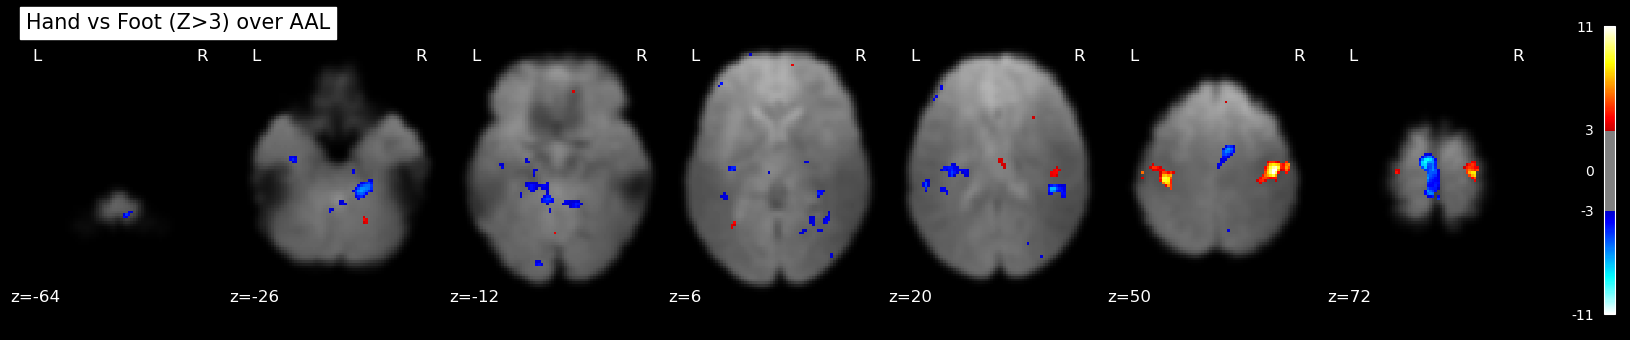

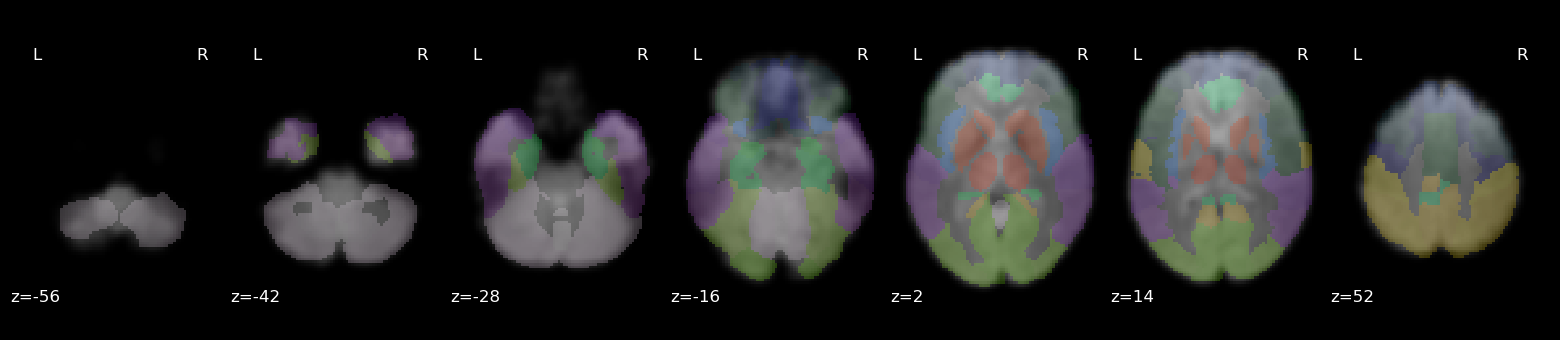

Top AAL regions (mean Z within label, positive side):
Precentral_R: 0.80
Postcentral_L: 0.79
Cerebelum_6_L: 0.71
Postcentral_R: 0.64
Frontal_Med_Orb_R: 0.64
Cerebelum_6_R: 0.59
Precentral_L: 0.56
Frontal_Med_Orb_L: 0.52
Frontal_Sup_Medial_R: 0.52
Cerebelum_4_5_L: 0.50


In [29]:
# Overlay AAL and report top regions
from nilearn.datasets import fetch_atlas_aal
from nilearn.image import resample_to_img
from nilearn.plotting import plot_stat_map, plot_roi
from nilearn.maskers import NiftiLabelsMasker
import numpy as np

# Load AAL
aal = fetch_atlas_aal(version='SPM12')  # downloaded to cache
aal_img = nib.load(aal.maps)
aal_labels = aal.labels

# Resample AAL to your functional/Z map space
z_map_img = nib.load(op.join(OUTDIR, "z_hand_vs_foot.nii.gz"))
aal_res = resample_to_img(aal_img, z_map_img, interpolation='nearest')

# Overlay (visual)
plot_stat_map(z_map_img, bg_img=mean_img(func_file), threshold=3.0,
              display_mode='z', cut_coords=7, black_bg=True,
              title='Hand vs Foot (Z>3) over AAL')
plot_roi(aal_res, bg_img=mean_img(func_file), display_mode='z', cut_coords=7, alpha=0.2)
plt.show()

# Quantify: mean Z per AAL label (only positive-contrast voxels)
data = z_map_img.get_fdata()
data[data < 0] = 0  # focus on hand>foot; remove negatives

masker = NiftiLabelsMasker(labels_img=aal_res, standardize=False)
mean_by_label = masker.fit_transform(z_map_img).ravel()  # mean within each label (includes negatives originally)

# Recompute with positive-only mask for cleaner "activation" means
pos_img = nib.Nifti1Image(data, z_map_img.affine)
mean_pos = masker.fit_transform(pos_img).ravel()

# Report top regions
top_k = 10
idx = np.argsort(mean_pos)[::-1][:top_k]
top_regions = [(aal_labels[i], float(mean_pos[i])) for i in idx if mean_pos[i] > 0]

print("Top AAL regions (mean Z within label, positive side):")
for name, val in top_regions:
    print(f"{name}: {val:.2f}")

# Part 2 (variant 3)

**K-Means Clustering**

Dataset X with  samples and  features.

Here, we apply K-means clustering on the subject fMRI runs, considering one volume as one sample.

In [1]:
import nibabel as nib
import numpy as np
import os

OUTDIR = "/neurodesktop-storage/nx421_sub-101410"
concat_file = os.path.join(OUTDIR, "tfMRI_MOTOR_concat_varscaled.nii.gz")
mask_file   = os.path.join(OUTDIR, "brainLR_mask.nii.gz")

img = nib.load(concat_file)
data = img.get_fdata()
affine = img.affine
print("Functional data shape:", data.shape)

mask = nib.load(mask_file).get_fdata().astype(bool)
print("Brain mask shape:", mask.shape)

# Apply mask to only keep brain voxels
data_masked = data[mask]  # shape = (n_voxels, n_volumes)
n_voxels, n_vols = data_masked.shape
print(f"Masked data shape: {data_masked.shape}  (voxels x volumes)")

# Remove temporal mean for each voxel (voxel-wise centering)
voxel_means = np.mean(data_masked, axis=1, keepdims=True)
X_centered = data_masked - voxel_means

print("Max residual voxel mean (should be ~0):", np.abs(X_centered.mean(axis=1)).max())

# Transpose for clustering
# Each row = timepoint (volume)
# Each column = voxel feature
X_kmeans = X_centered.T
print("Matrix shape for K-means (volumes x voxels):", X_kmeans.shape)

Functional data shape: (91, 109, 91, 568)
Brain mask shape: (91, 109, 91)
Masked data shape: (232336, 568)  (voxels x volumes)
Max residual voxel mean (should be ~0): 8.006115332508171e-16
Matrix shape for K-means (volumes x voxels): (568, 232336)


K-means is a clustering method enabling components extraction. Leveraging a given definition of distance (i.e cosine distance, euclidean distance etc...), K-means finds distance minimizing components to cover all samples. We will consider timepoints to be samples and voxels to be features. Clustering would yield the main spatial patterns that "appear" during the timecourse.

To apply K-Means, we can use scikit-learn KMeans implementation: [KMeans](https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html)

In [2]:
from sklearn.cluster import KMeans

max_nb_clusters = 10
avg_dist_samples = []
for nb_cluster in range(1, max_nb_clusters):
    kmeans = KMeans(n_clusters=nb_cluster, random_state=0, n_init="auto").fit(X_kmeans)
    avg_dist_samples.append(kmeans.inertia_)

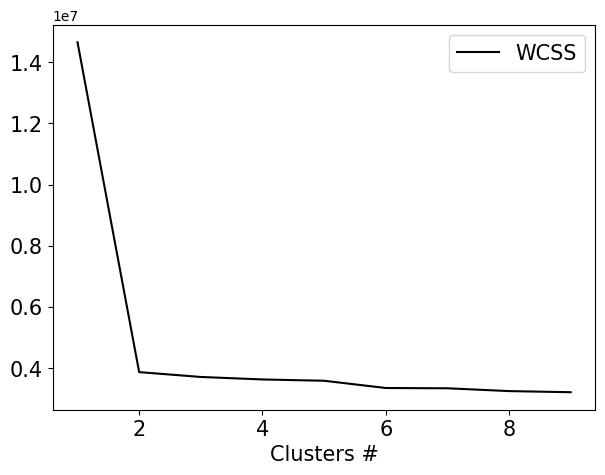

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(7,5))

ax.plot(np.arange(1, len(avg_dist_samples)+1), avg_dist_samples, label='WCSS', c='k')

ax.set_xlabel('Clusters #', size=15)
ax.legend(prop={'size':15})
ax.tick_params(axis='both', which='major', labelsize=15)

In [4]:
nb_clusters = 7 # Either use the number of experimental conditions or choose based on the elbow method that shows when is that the WCSS reduction is not significant anymore
kmeans = KMeans(n_clusters=nb_clusters, random_state=0, n_init="auto").fit(X_kmeans)

vol_shape = data.shape[:-1]         
mask_bool = mask                     

kmeans_clusters = []
for cluster_idx in range(nb_clusters):
    kmeans_component = np.zeros(vol_shape)
    kmeans_component[mask_bool] = kmeans.cluster_centers_[cluster_idx]
    kmeans_clusters.append(kmeans_component)

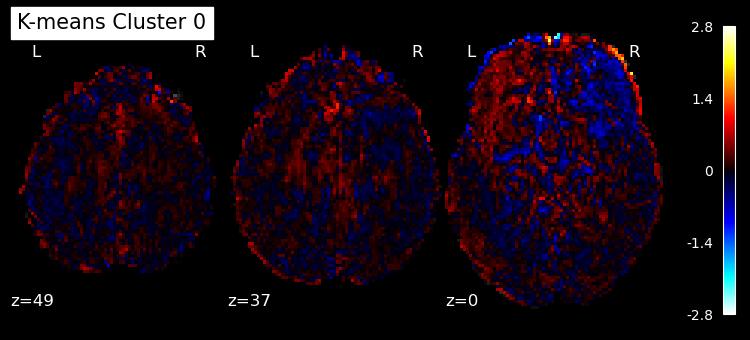

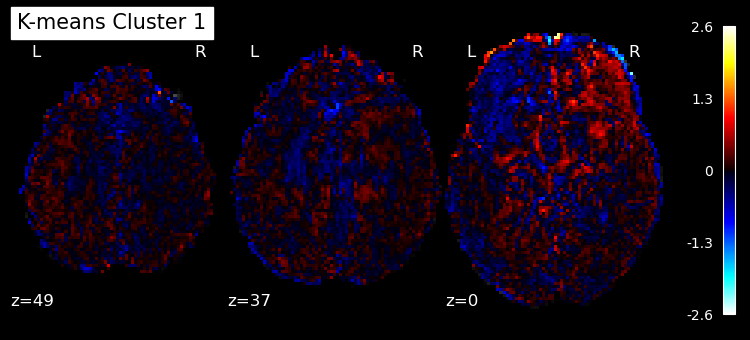

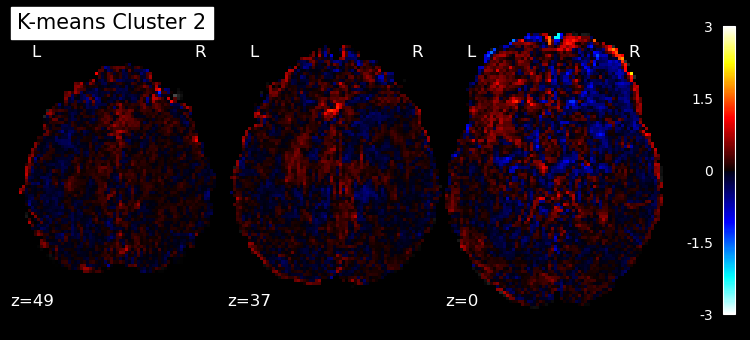

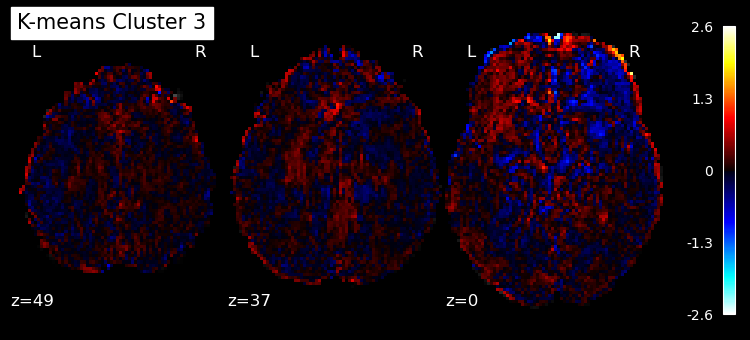

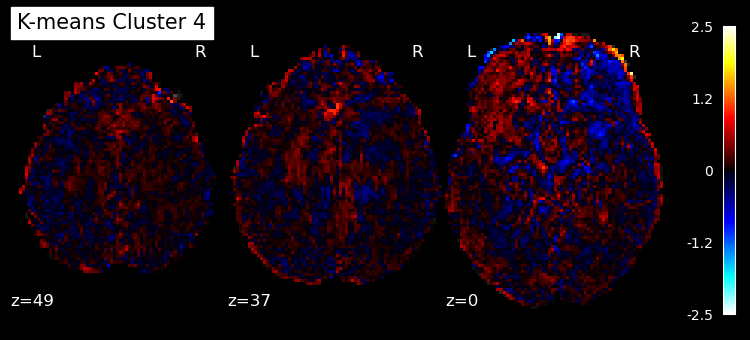

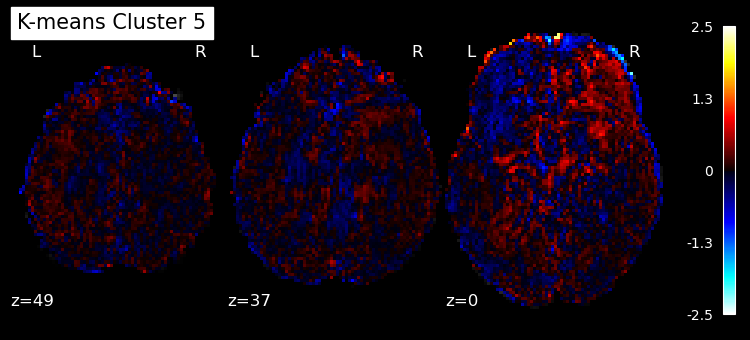

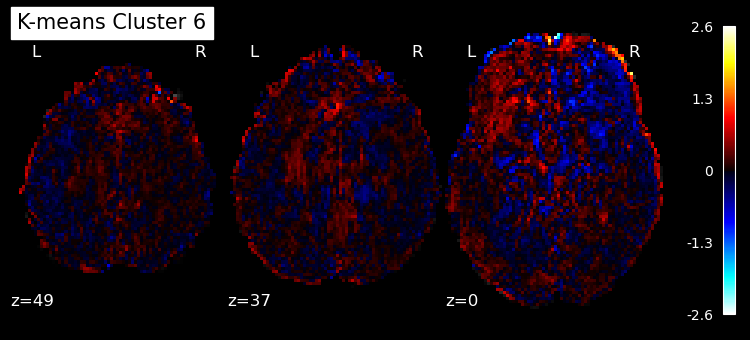

In [5]:
from nilearn.datasets import fetch_atlas_aal
from nilearn.image import resample_to_img
from nilearn.plotting import plot_stat_map, plot_roi
from nilearn.maskers import NiftiLabelsMasker
import numpy as np
import sys
import os
from nilearn.plotting import plot_stat_map
from nilearn.image import mean_img
import nibabel as nib
import numpy as np
import os
mean_img_ = mean_img(img)
for visual_idx in np.arange(0, nb_clusters):
    plot_stat_map(nib.Nifti1Image(kmeans_clusters[visual_idx], affine), display_mode="z", bg_img=mean_img_, threshold=0,
                   cut_coords=[49,37,00], black_bg=True,
                  title=f'K-means Cluster {visual_idx}')

    plt.show()

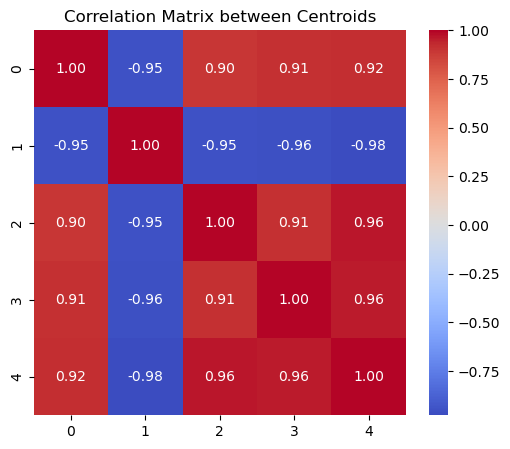

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
centroids = kmeans.cluster_centers_

df_centroids = centroids[:5,:]
df_centroids = pd.DataFrame(df_centroids, columns=[f'Feature_{i+1}' for i in range(centroids.shape[1])])
corr_matrix = df_centroids.T.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix between Centroids")
plt.show()